# FEEMS: Run — MalariaGEN data

**Kernel**: `FEEMS (mgendata)`  
**Prerequisite**: run `prepare_feems_inputs.ipynb` first — it writes the PLINK files, sample coordinates, and outer boundary.

Steps:
1. Load PLINK genotypes
2. Load metadata and align coordinates to Plink FAM order
3. Filter to segregating SNPs
4. Build `SpatialGraph` object
5. Plot sample positions on unfit graph
6. Initial fit at λ=20
7. Cross-validation to select λ
8. Final fit and visualise effective migration surface
9. Export node positions and edge weights

In [22]:
# Import dependencies

import numpy as np
import pandas as pd
import glob, os
from importlib.resources import files as _res_files
from sklearn.impute import SimpleImputer
from pandas_plink import read_plink

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.axes import Axes
from cartopy.mpl.geoaxes import GeoAxes

from feems.utils import prepare_graph_inputs
from feems.cross_validation import run_cv
from feems import SpatialGraph, Viz

GeoAxes._pcolormesh_patched = Axes.pcolormesh

In [ ]:
import os, glob

# ── USER CONFIG ────────────────────────────────────────────────────────────
study_taxon  = 'funestus'         # must match prepare_feems_inputs.ipynb
study_region = 'Kenya'            # single country string, or list e.g. ['Kenya', 'Tanzania']
study_prefix = 'funestus-kenya'   # used for file names and plot titles

grid_res_km = 50    # must match prepare_feems_inputs.ipynb
outdir      = 'feems_outputs'
# ──────────────────────────────────────────────────────────────────────────

shp_dir = f'{outdir}/shapefiles'

_bed_files = sorted(glob.glob(f'{outdir}/plink/*.bed'))
assert _bed_files, f"No .bed files in {outdir}/plink/ — run prepare_feems_inputs.ipynb first"
bed_path = _bed_files[0][:-4]
print(f'PLINK prefix: {bed_path}')

## 1. Load genotype data

In [30]:
(bim, fam, G) = read_plink(bed_path)
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
genotypes = imp.fit_transform(np.array(G).T)
print(f'n_samples={genotypes.shape[0]}, n_snps={genotypes.shape[1]}')

Mapping files: 100%|██████████| 3/3 [00:00<00:00, 46.28it/s]


n_samples=573, n_snps=124587


## 2. Load metadata and align coordinates to FAM order

`prepare_feems_inputs.ipynb` saves `sample_coords_{study_region}.csv` with one row per sample in the same order as the AF1 metadata query. We merge on `sample_id` (== FAM IID) so the coordinate rows stay aligned with genotype rows regardless of sort order.

In [ ]:
coords_path = f'{outdir}/sample_coords_{study_prefix}.csv'
meta = pd.read_csv(coords_path)

df_samples = fam[['iid']].merge(
    meta[['sample_id', 'longitude', 'latitude']],
    left_on='iid', right_on='sample_id', how='left',
)
assert len(df_samples) == genotypes.shape[0], 'sample count mismatch after merge'

miss_bool = df_samples[['latitude', 'longitude']].isna().any(axis=1).values
if miss_bool.sum() > 0:
    print(f'Dropping {miss_bool.sum()} samples with missing coordinates')
    genotypes  = genotypes[~miss_bool]
    df_samples = df_samples[~miss_bool].reset_index(drop=True)

coord = df_samples[['longitude', 'latitude']].to_numpy()
print(f'Samples with coords: {len(coord)}')
print(df_samples[['sample_id', 'latitude', 'longitude']].head(5))

## 3. Filter to segregating SNPs and handle missing coordinates

In [26]:
seg_bool = (genotypes.sum(axis=0) > 0) & (genotypes.sum(axis=0) < genotypes.shape[0] * 2)
genotypes = genotypes[:, seg_bool]
print(f'After seg-site filter: n_samples={genotypes.shape[0]}, n_snps={genotypes.shape[1]}')

After seg-site filter: n_samples=573, n_snps=124587


## 4. Build spatial graph

In [ ]:
if grid_res_km == 100:
    grid_path = str(_res_files('feems').joinpath('data/grid_100.shp'))
elif grid_res_km == 500:
    grid_path = str(_res_files('feems').joinpath('data/grid_500.shp'))
else:
    grid_path = f'{shp_dir}/feems_grid_{grid_res_km}km.shp'
    assert os.path.exists(grid_path), \
        f'Grid not found at {grid_path} — run prepare_feems_inputs.ipynb first'

outer_coords = pd.read_csv(f'{shp_dir}/outer_{study_prefix}.csv').to_numpy()

outer, edges, grid, _ = prepare_graph_inputs(
    coord=coord, ggrid=grid_path, translated=False, buffer=0, outer=outer_coords,
)

sp_graph = SpatialGraph(genotypes, coord, grid, edges, scale_snps=True)
print(f'SpatialGraph: {len(sp_graph.nodes)} nodes, {len(sp_graph.edges)} edges')
print(f'Observed nodes (with samples): {sp_graph.n_observed_nodes}')

## 5. Visualise graph without fitting 

In [ ]:
lon_c = np.mean([outer_coords[:, 0].min(), outer_coords[:, 0].max()])
lat_c = np.mean([outer_coords[:, 1].min(), outer_coords[:, 1].max()])
projection = ccrs.EquidistantConic(central_longitude=lon_c, central_latitude=lat_c)

fig = plt.figure(dpi=200)
ax = fig.add_subplot(1, 1, 1, projection=projection)
ax._autoscaleXon = False
ax._autoscaleYon = False

v = Viz(ax, sp_graph, projection=projection, edge_width=0.5,
        edge_alpha=1, edge_zorder=100, sample_pt_size=10,
        obs_node_size=7.5, sample_pt_color='black', cbar_font_size=10)
v.draw_map()
v.draw_samples()
v.draw_edges(use_weights=False)
v.draw_obs_nodes(use_ids=False)
plt.title(f'An. {study_taxon} — {study_prefix} — unfit graph')
plt.tight_layout()
plt.show()

## 6. Initial fit (λ = 20)

In [8]:
sp_graph.fit(lamb=20.0, optimize_q=None)

In [ ]:
fig = plt.figure(dpi=200)
ax = fig.add_subplot(1, 1, 1, projection=projection)
ax._autoscaleXon = False
ax._autoscaleYon = False

v = Viz(ax, sp_graph, projection=projection, edge_width=0.5,
        edge_alpha=1, edge_zorder=100, sample_pt_size=20,
        obs_node_size=7.5, sample_pt_color='black', cbar_font_size=10)
v.draw_map()
v.draw_samples()
v.draw_edges(use_weights=True)
v.draw_obs_nodes(use_ids=False)
plt.title(f'An. {study_taxon} — {study_prefix} — λ=20')
plt.tight_layout()
plt.show()

## 7. Cross-validation to select λ

In [10]:
# reversed for warmstart
lamb_grid = np.geomspace(1e-6, 1e2, 20)[::-1]

cv_err = run_cv(sp_graph, lamb_grid, n_folds=sp_graph.n_observed_nodes, factr=1e10)
mean_cv_err = np.mean(cv_err, axis=0)

lamb_cv = float(lamb_grid[np.argmin(mean_cv_err)])
print(f'Best lambda: {lamb_cv:.4e}')


 fold:  0
iteration lambda=20/20 alpha=1/1
 fold:  1
iteration lambda=20/20 alpha=1/1
 fold:  2
iteration lambda=20/20 alpha=1/1
 fold:  3
iteration lambda=20/20 alpha=1/1
 fold:  4
iteration lambda=20/20 alpha=1/1
 fold:  5
iteration lambda=20/20 alpha=1/1
 fold:  6
iteration lambda=20/20 alpha=1/1Best lambda: 3.7927e+01


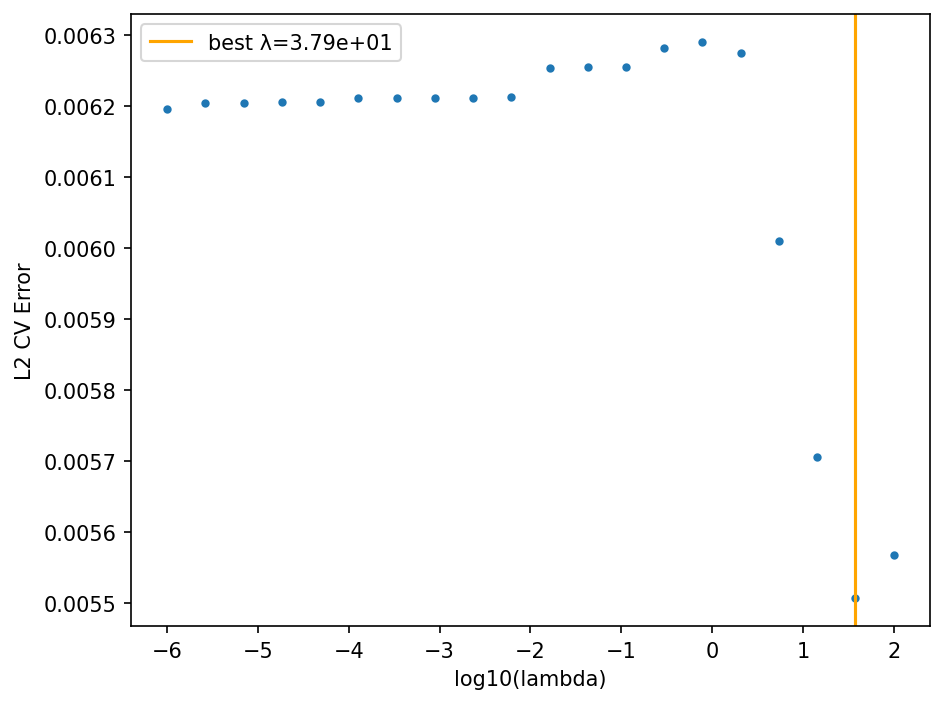

In [21]:
fig, ax = plt.subplots(dpi=150)
ax.plot(np.log10(lamb_grid), mean_cv_err, '.')
ax.set_xlabel('log10(lambda)')
ax.set_ylabel('L2 CV Error')
ax.axvline(np.log10(lamb_cv), color='orange', label=f'best λ={lamb_cv:.2e}')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
from matplotlib import gridspec

edge_width = 0.2
obs_node_size = 3
cbar_font_size = 8
cbar_ticklabelsize = 8
cbar_orientation = 'horizontal'

fig = plt.figure(dpi=200)
spec = gridspec.GridSpec(ncols=2, nrows=2, figure=fig, wspace=0.0, hspace=0.0)

panels = [
    (spec[0, 0], 'A', float(lamb_grid[0])),
    (spec[1, 0], 'B', float(lamb_grid[3])),
    (spec[0, 1], 'C', float(lamb_cv)),
    (spec[1, 1], 'D', float(lamb_grid[10])),
]

for i, (sp, label, lam) in enumerate(panels):
    ax = fig.add_subplot(sp, projection=projection)
    ax._autoscaleXon = False
    ax._autoscaleYon = False
    ax.set_title(label, loc='left', pad=-10, fontdict={'fontsize': 12})
    sp_graph.fit(lam, optimize_q=None)
    v = Viz(ax, sp_graph, projection=projection, edge_width=edge_width,
            edge_alpha=1, edge_zorder=100, sample_pt_size=20,
            obs_node_size=obs_node_size, sample_pt_color='black',
            cbar_font_size=cbar_font_size)
    v.draw_map()
    v.draw_edges(use_weights=True)
    v.draw_obs_nodes(use_ids=False)
    cv_idx = np.where(lamb_grid == lam)[0]
    cv_val = mean_cv_err[cv_idx[0], 0] if len(cv_idx) else float('nan')
    ax.text(0.2, 0.85, f'lambda={lam:.5f}\ncv l2 error={cv_val:.5f}',
            fontdict={'fontsize': 4}, transform=ax.transAxes)
    if i == 3:
        v.cbar_font_size = cbar_font_size
        v.cbar_orientation = cbar_orientation
        v.cbar_ticklabelsize = cbar_ticklabelsize
        v.draw_edge_colorbar()

plt.suptitle(f'An. {study_taxon} — {study_prefix} — lambda sweep', fontsize=10)
plt.tight_layout()
plt.show()

## 8. Final fit with optimal λ

In [ ]:
sp_graph.fit(lamb_cv, optimize_q=None)

fig = plt.figure(dpi=200)
ax = fig.add_subplot(1, 1, 1, projection=projection)
ax._autoscaleXon = False
ax._autoscaleYon = False

v = Viz(ax, sp_graph, projection=projection, edge_width=0.5,
        edge_alpha=1, edge_zorder=100, sample_pt_size=20,
        obs_node_size=7.5, sample_pt_color='black', cbar_font_size=10)
v.draw_map()
v.draw_edges(use_weights=True)
v.draw_obs_nodes(use_ids=False)
v.draw_edge_colorbar()

plt.title(f'FEEMS: An. {study_taxon} — {study_prefix} (λ={lamb_cv:.2e})')
plt.tight_layout()

out_path = f'{outdir}/feems_{study_prefix}_surface.pdf'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## 8. Export results

Node positions (with sample counts) and edge weights for downstream plotting.

In [ ]:
node_path = f'{outdir}/feems_{study_prefix}_node_positions.csv'
edge_path = f'{outdir}/feems_{study_prefix}_edge_weights.csv'

np.savetxt(
    node_path,
    np.vstack((
        sp_graph.node_pos.T,
        [sp_graph.nodes[n]['n_samples'] for n in range(len(sp_graph.nodes))],
    )).T,
    delimiter=',', header='lon,lat,n_samples', comments='',
)

np.savetxt(
    edge_path,
    np.vstack((np.array(sp_graph.edges).T, sp_graph.w)).T,
    delimiter=',', header='node_i,node_j,weight', comments='',
)

print(f'Node positions → {node_path}')
print(f'Edge weights   → {edge_path}')